#### Mount to Google Drive

In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')
# Aditya
# %cd drive/MyDrive/GenAI/"Final Project"
# Gorkem
%cd /content/drive/Othercomputers/'My MacBook Pro'/SISO_original/SISO_reimplemented

dino_file_check = os.path.exists("./dino_utils.py") and os.path.isfile("./dino_utils.py")
ir_file_check = os.path.exists("./ir_features_utils.py") and os.path.isfile("./ir_features_utils.py")
general_file_check = os.path.exists("./general_utils.py") and os.path.isfile("./general_utils.py")
assert (dino_file_check and ir_file_check and general_file_check), "Not all files are present"

Mounted at /content/drive
/content/drive/Othercomputers/My MacBook Pro/SISO_original/SISO_reimplemented


#### Install required libraries

In [2]:
!pip install torch>=1.9 torchvision ftfy regex huggingface_hub
!pip install -q diffusers matplotlib accelerate peft kornia tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 75.1 MB/s eta 0:00:00


In [3]:
!pip install git+https://github.com/mlfoundations/open_clip

  Cloning https://github.com/mlfoundations/open_clip to /tmp/pip-req-build-vjx3hwgj
  Running command git clone --filter=blob:none --quiet https://github.com/mlfoundations/open_clip /tmp/pip-req-build-vjx3hwgj
  Resolved https://github.com/mlfoundations/open_clip to commit bf5d49c112c82c738f7b34bde6e154760a711790
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for open_clip_torch: filename=open_clip_torch-2.32.0-py3-none-any.whl size=1528783 sha256=7e296d0f66fefdbbfec5b6dbb7653f697a1757297dcecafd3dbdc386efb13f21
  Stored in directory: /tmp/pip-ephem-wheel-cache-tkyioe38/wheels/4d/bb/a0/8b232280514f73560f9546bb17141fabc6f79f9ac30790ce68
Successfully built open_clip_torch


In [4]:
import open_clip
custom_config = open_clip.get_model_config("ViT-H-14")
custom_config["vision_cfg"]["image_size"] = 336

# Register it under the paper's name
open_clip.factory._MODEL_CONFIGS["ViT-H-14-290"] = custom_config
print(open_clip.factory._MODEL_CONFIGS['ViT-H-14-290'])

{'embed_dim': 1024, 'vision_cfg': {'image_size': 336, 'layers': 32, 'width': 1280, 'head_width': 80, 'patch_size': 14}, 'text_cfg': {'context_length': 77, 'vocab_size': 49408, 'width': 1024, 'heads': 16, 'layers': 24}}


In [5]:
# %cd /content/drive/Othercomputers/'My MacBook Pro'/SISO_original/SISO_reimplemented
# %cd third_party/IR_dependencies/open_clip_280
# !pip install -e .
# %cd "../open_clip_280_overlap"
# !pip install -e .
# %cd /content/drive/Othercomputers/'My MacBook Pro'/SISO_original/SISO_reimplemented

import kagglehub
# Download latest version
path = kagglehub.dataset_download("louieshao/guieweights0732")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/guieweights0732


# SISO Reimplemented

#### Import required libraries

In [6]:
import numpy as np
from transformers import CLIPTextModel, CLIPTokenizer, CLIPTextModelWithProjection
from diffusers import (
    DDPMScheduler,
    DiffusionPipeline,
    AutoencoderKL,
    UNet2DConditionModel
)
from pipeline_stable_diffusion_xl_with_grads import StableDiffusionXLPipelineWithGrads
import torch
import torchvision
from peft import LoraConfig, get_peft_model
from accelerate import Accelerator
import matplotlib.pyplot as plt
from pprint import pprint
from tqdm import tqdm
from diffusers.optimization import get_scheduler

import dino_utils as dino_utils
import ir_features_utils as ir_features_utils
import general_utils as general_utils

#### Configurations

In [7]:
gradient_accumulation_steps = 1
max_train_steps = 1000
num_train_epochs = 100

LR = 1E-3
lr_scheduler_type = "constant"
lr_warmup_steps = 500

ADAM_BETAS = (0.9, 0.999)
ADAM_WEIGHT_DECAY = 1e-2
ADAM_EPSILON = 1e-8

LORA_RANK = 32
LORA_ALPHA = 8

dino_weight = 1.0
ir_weight = 1.0

#### Subject Image

In [8]:
# deneme
image_path = "./cat2.png"
subject_image = general_utils.load_image(image_path)
subject_image_arr = general_utils.image_to_tensor(subject_image)

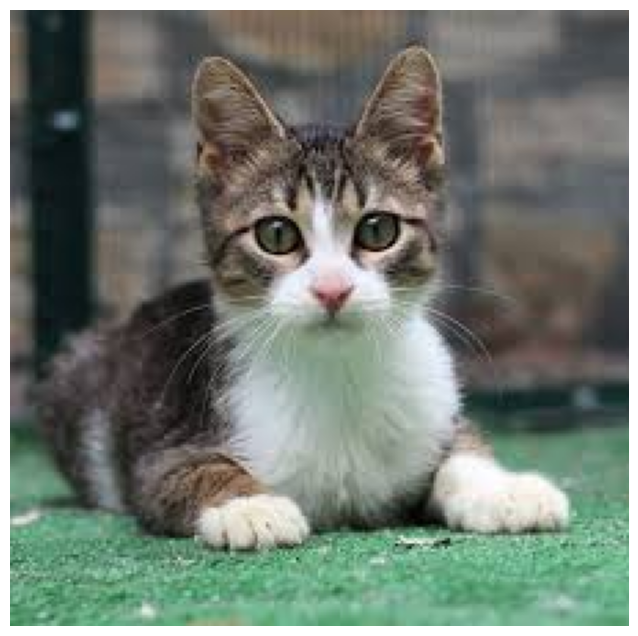

In [9]:
# view subject image
plt.figure(figsize=(8, 8))
plt.imshow(subject_image_arr.squeeze(0).permute(1, 2, 0))
plt.axis('off')
plt.show()

#### Accelerator && Pretrained Models

In [10]:
accelerator = Accelerator(gradient_accumulation_steps=gradient_accumulation_steps)
device = accelerator.device

In [11]:
model_path = "stabilityai/sdxl-turbo"

In [12]:
"""
  Refer to
    https://huggingface.co/docs/diffusers/en/training/lora
    https://github.com/huggingface/diffusers/blob/e4b8f173b97731686e290b2eb98e7f5df2b1b322/examples/text_to_image/train_text_to_image_lora.py

"""

noise_scheduler = DDPMScheduler.from_pretrained(model_path, subfolder="scheduler")
tokenizer = CLIPTokenizer.from_pretrained(model_path, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_path, subfolder="text_encoder")
text_encoder_2 = CLIPTextModelWithProjection.from_pretrained(model_path, subfolder="text_encoder_2")
unet = UNet2DConditionModel.from_pretrained(model_path, subfolder="unet")
vae = AutoencoderKL.from_pretrained(model_path, subfolder="vae")

vae.requires_grad_(False)
text_encoder.requires_grad_(False)
text_encoder_2.requires_grad_(False)
unet.requires_grad_(False)

lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
)

unet.add_adapter(lora_config)
# vae.add_adapter(lora_config)
lora_layers = list(filter(lambda p: p.requires_grad, unet.parameters()))

optimizer = torch.optim.AdamW(
    lora_layers,
    lr=LR,
    betas=ADAM_BETAS,
    weight_decay=ADAM_WEIGHT_DECAY,
    eps=ADAM_EPSILON
)

lr_scheduler = get_scheduler(
    lr_scheduler_type,
    optimizer=optimizer,
    num_warmup_steps=lr_warmup_steps * gradient_accumulation_steps,
    num_training_steps=num_train_epochs,
)
unet, optimizer, lr_scheduler = accelerator.prepare(unet, optimizer, lr_scheduler)
# unet, vae, optimizer = accelerator.prepare(unet, vae, optimizer)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


scheduler_config.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/704 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.78G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.78k [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/10.3G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

In [13]:
# # See https://github.com/yairshp/SISO/blob/main/siso_generation_sdxl.py#L799-L827

dino_model_path = "vit_large_patch14_dinov2.lvd142m"
dino_criterion  = dino_utils.get_dino_features_negative_mean_cos_sim
dino, transforms_configs = (dino_utils.get_model_and_transforms_configs(dino_model_path))
dino_subject_image_input = dino_utils.prepare_for_dino(subject_image_arr, transforms_configs).cuda()
with torch.no_grad():
    dino_subject_image_features = dino_utils.get_dino_features(
        dino, dino_subject_image_input
    )

## IR Loss
new_path = path + "/arcface all vith 18 last and middle first 3 280 all 3 290 first 1 overlap last 6 middle 6 first 3 dropout.pth"

ir_criterion = ir_features_utils.get_ir_features_negative_mean_cos_sim
ir_feature_extractor, feature_extractor_transforms = (
          ir_features_utils.get_ir_model_and_transforms(
              new_path,
              #"third_party/IR_dependencies/ir_features.pth",
              device=device
          )
      )
ir_feature_extractor.eval()
ir_feature_extractor = ir_feature_extractor.to(device)
with torch.no_grad():
    ir_subject_image_features = ir_features_utils.get_ir_features(
        ir_feature_extractor, feature_extractor_transforms, subject_image_arr
    )


model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

/content/drive/Othercomputers/My MacBook Pro/SISO_original/SISO_reimplemented/dino_utils.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(transforms_configs["normalize_mean"]),
/content/drive/Othercomputers/My MacBook Pro/SISO_original/SISO_reimplemented/dino_utils.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(transforms_configs["normalize_std"]),


In [19]:
# TODO: Implement smarter stopping criteria
# Iterative Optimization
PYTORCH_CUDA_ALLOC_CONF=True
pipeline = StableDiffusionXLPipelineWithGrads.from_pretrained(
        model_path,
        vae=vae,
        text_encoder=text_encoder,
        text_encoder_2=text_encoder_2,
        unet=unet
    ).to(device)

STOPPING_ITER = 30
prompt = "Image of cat next to a red ball"

first_image = None
best_loss = float("inf")
best_image = None

for iter in range(STOPPING_ITER):
    optimizer.zero_grad()
    generator = torch.Generator(device=accelerator.device)
    generator.manual_seed(42)

  # generate image
  # with accelerator.accumulate(unet):
    image = (pipeline(
                  prompt=prompt,
                  num_inference_steps=4,
                  output_type="pt",
                  height=336,
                  width=336,
                  generator=generator,
                  guidance_scale=0.0,
              )
              .images[0]
              .unsqueeze(0))
    # Save first image
    if iter == 0:
      first_image = image

    # calculate loss
    dino_loss = dino_criterion(
                      dino,
                      transforms_configs,
                      image,
                      dino_subject_image_features,
                  )
    ir_loss = ir_criterion(
                ir_feature_extractor,
                feature_extractor_transforms,
                image,
                ir_subject_image_features,
            )
    loss = dino_loss * dino_weight + ir_loss * ir_weight

    # save best loss/image
    if abs(loss.detach().item()) < abs(best_loss):
      best_loss = loss.detach().item()
      best_image = image

    # finetune model
    accelerator.backward(loss)
    optimizer.step()

    print(f"Loss {iter}: {loss.detach().item()}")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Loss 0: -1.6580017805099487


  0%|          | 0/4 [00:00<?, ?it/s]

Loss 1: -1.6699028015136719


...

Loss 27: -1.7936668395996094


  0%|          | 0/4 [00:00<?, ?it/s]

Loss 28: -1.8000400066375732


  0%|          | 0/4 [00:00<?, ?it/s]

Loss 29: -1.822460651397705


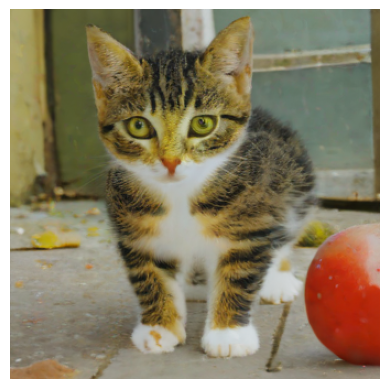

In [20]:
plt.imshow(first_image.detach().cpu().squeeze().permute(1,2,0))
plt.axis('off')
plt.show()

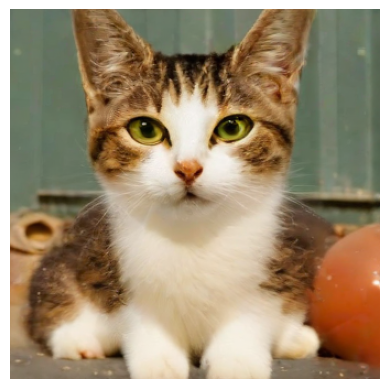

In [21]:
plt.imshow(image.detach().cpu().squeeze().permute(1,2,0))
plt.axis('off')
plt.show()

In [22]:
del pipeline
torch.cuda.empty_cache()